# `SurfTrack`: temporal neighbor labelling and overlap threshold
SurfTrack operates on 3-D data `(time, lat, lon)` and runs four steps:
1. **Morphological close→open** cleans each 2-D slice independently
2. **Area filtering** removes objects below a size threshold
3. **Labelling** — two methods are available:
   - `method='3d'` runs connected-component labelling on the full `(time, lat, lon)` volume at once. Blobs can link across any number of timesteps as long as there is an unbroken 3-D path, including diagonal connections through time.
   - `method='temporal_neighbor'` labels each 2-D frame independently, then links blobs between adjacent frames only if they spatially overlap. A gap of even one timestep starts a new event. Two parameters control this:
     - `steps_before`, `steps_after` — how many timesteps back and forward a blob can link (default 1)
     - `min_overlap` — minimum shared pixels required to merge two blobs, either as an absolute pixel count (int) or a fraction of the smaller blob's area (float)
4. **Date-line wrapping** merges events that straddle the 0°/360° boundary

For subsurface (4-D) tracking see the **DeepTrack** tutorial.

### Imports

In [1]:
import sys
import os

# Go up from notebooks/ to repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, repo_root)

In [2]:
from ocetrac.SurfTrack import SurfTracker
from ocetrac.preprocessing.cesm2_lens_utils import get_ds_var
from ocetrac.preprocessing.preprocessing import calculate_anomalies_trend_features

In [3]:
import numpy as np
import xarray as xr

import cmocean
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from skimage.measure import label as label_np
import scipy 
from scipy import ndimage

import warnings

warnings.filterwarnings("ignore", message=".*decode the variable.*")
warnings.filterwarnings("ignore", message=".*default value for data_vars.*")

### 2. Data loading

This section loads CESM2 Large Ensemble (CESM2-LENS) SST data for a single ensemble member. The CESM2-LE provides 100 ensemble members spanning 1850-2100.
- Component: `atm` (atmosphere model component)
- Temporal resolution: Monthly means

In [4]:
%%time

ens_memb_index = 0
var, comp  = 'SST', 'atm'
directory  = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'

ds_hist, _ = get_ds_var(directory, var, comp, ens_memb_index)

nlat_low, nlat_high = 26, 328
da_sst = ds_hist[var].sel(
    lat=slice(-65, 65),
    time=slice('1979-01', '2015-01')).compute()

print(f"Loaded: {da_sst.dims}  {da_sst.shape}")

Loaded: ('time', 'lat', 'lon')  (433, 138, 288)
CPU times: user 1.83 s, sys: 526 ms, total: 2.36 s
Wall time: 5.05 s


In [5]:
# Replace 0s with NaN (land masking)
da_sst_noland = da_sst.where(da_sst != 0, np.nan)

### 3. Anomaly computation

This preprocessing step is separate from the Ocetrac tracking algorithm. It prepares the temperature field by the trend and seasonality.

This example notebook uses `preprocessing.calculate_anomalies_trend_features`, which fits a 6-coefficient harmonic model per grid cell and returns the residual as well as provides the features. 

In [6]:
%%time

mean, trend, seas, features, anom = calculate_anomalies_trend_features(
    da_sst, 
    0.9)

print(f"features shape: {features.shape}  ({features.nbytes/1e9:.2f} GB)")

features shape: (433, 138, 288)  (0.14 GB)
CPU times: user 1.39 s, sys: 71.1 ms, total: 1.46 s
Wall time: 2.25 s


In [7]:
# Subset first 40 timesteps (months) for tutorial
features = features.isel(time=slice(40))

In [8]:
da_sst_noland = da_sst.where(da_sst != 0, np.nan)

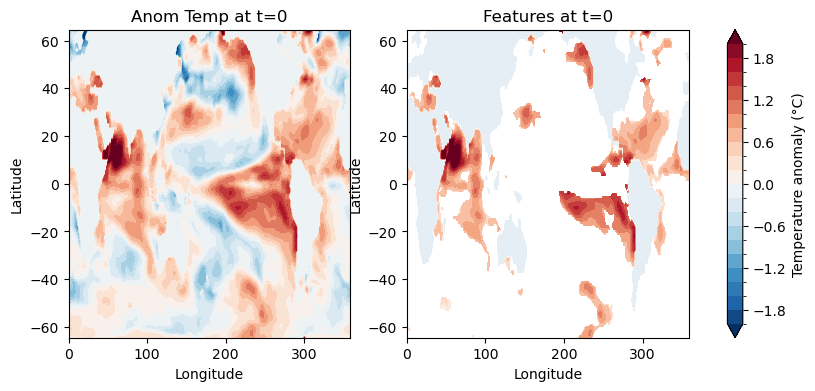

In [9]:
## -------------- Figure of anom temperature and features

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = anom[30, :, :].plot.contourf(
    ax=ax1,
    levels=21, 
    vmin=-2, 
    vmax=2, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax1.set_title('Anom Temp at t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = features[30, :, :].plot.contourf(
    ax=ax2,
    levels=21, 
    vmin=-2, 
    vmax=2, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax2.set_title('Features at t=0', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Temperature anomaly (°C)', fontsize=10)

plt.show()

### 4. Build the ocean mask

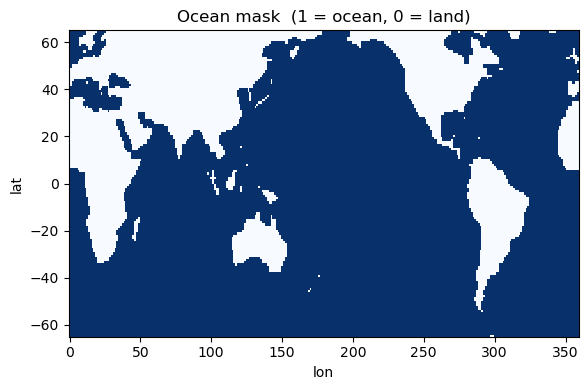

In [10]:
mask = xr.where(da_sst[0,:,:] == 0., 0., 1.)

fig, ax = plt.subplots(figsize=(6, 4))
mask.plot(ax=ax, cmap='Blues', add_colorbar=False)
ax.set_title('Ocean mask  (1 = ocean, 0 = land)')
plt.tight_layout(); plt.show(); plt.close()

### 5. Initialise and run the tracker

#### Parameters

| Parameter | Description |
|---|---|
| `radius` | Structuring element radius for morphological close→open. Larger values fill wider gaps but risk bridging nearby separate events. |
| `min_size_quartile` | Drop blobs below this percentile of the area distribution. Combined with `min_area_cells` via `max()`. |
| `min_area_cells` | Absolute minimum blob size in grid cells. Always applied regardless of the percentile. |
| `positive` | `True` → track warm anomalies; `False` → cold. |
| `method` | `"3d"` (default) runs connected-component labelling on the full `(time, lat, lon)` volume. `"temporal_neighbor"` labels each 2-D frame independently and only links blobs between timesteps if they spatially overlap. |
| `steps_before` | `method="temporal_neighbor"` only. How many timesteps back a blob can link. Default 1. |
| `steps_after` | `method="temporal_neighbor"` only. How many timesteps forward a blob can link. Default 1. |
| `min_overlap` | `method="temporal_neighbor"` only. Minimum shared pixels to merge two blobs. Pass an `int` for an absolute pixel count or a `float` (0–1) for a fraction of the smaller blob's area. Default 1. |

#### Method comparison

| | `method="3d"` | `method="temporal_neighbor"` |
|---|---|---|
| Connectivity | Full 3-D volume at once | Adjacent timesteps only |
| Gap tolerance | Bridges gaps diagonally | Gap of 1 timestep = new event |
| Event count | Fewer, longer events | More, shorter events |
| Extra parameters | — | `steps_before`, `steps_after`, `min_overlap` |
| Backwards compatible | ✓ default | opt-in |

In [13]:
tracker2 = SurfTracker(
    features, 
    mask,
    radius=2, 
    min_size_quartile=0.25, 
    min_area_cells=100,
    timedim='time', 
    xdim='lon', 
    ydim='lat',
    method='temporal_neighbor',
    steps_before=1, 
    steps_after=1,
    min_overlap=0.5,
)
result = tracker2.run()
tracker2.summary()

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)
Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)
Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 87
Step 4 · wrapping result …
    final events: 87
final events: 87


In [26]:
print("Attributes:")
for k, v in result.attrs.items():
    print(f"  {k:<30} {v}")

Attributes:
  initial objects identified     791
  final objects tracked          87
  radius                         2
  size quantile threshold        0.25
  min area cells                 100
  min area (effective)           100.0
  percent area reject            0.10522655374881522
  percent area accept            0.8947734462511848


In [24]:
# compared to the 3d method which is what SurfTracker defaults to
tracker_3d = SurfTracker(
    features, 
    mask,
    radius=2, 
    min_size_quartile=0.25, 
    min_area_cells=100,
    timedim='time', 
    xdim='lon', 
    ydim='lat',
    method='3d',
)
result3d = tracker_3d.run()
tracker_3d.summary()

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)
Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)
Step 3 · labelling (method='3d') …
    initial objects : 791
    final objects   : 60
Step 4 · wrapping result …
    final events: 60
SurfTracker — Result Summary
  Input shape    : (40, 138, 288)
  Tracked events : 60
  Duration  min/median/max : 1 / 1 / 22
    >=  1 ts : 60
    >=  3 ts : 20
    >=  6 ts : 11
    >= 12 ts : 5

  Parameters:
    radius               = 2
    min_area_cells       = 100
    min_size_quartile    = 0.25
    positive             = True
    method               = 3d
    steps_before         = 1
    steps_after          = 1
    min_overlap          = 1


In [25]:
print("Attributes:")
for k, v in result3d.attrs.items():
    print(f"  {k:<30} {v}")

Attributes:
  initial objects identified     791
  final objects tracked          60
  radius                         2
  size quantile threshold        0.25
  min area cells                 100
  min area (effective)           100.0
  percent area reject            0.10522655374881522
  percent area accept            0.8947734462511848


## Run steps separately

In [ ]:
tracker2 = SurfTracker(
    features, mask,
    radius=2, min_size_quartile=0.25, min_area_cells=100,
    timedim='time', xdim='lon', ydim='lat',
    method='temporal_neighbor',
    steps_before=1, steps_after=1,
    min_overlap=0.5,
)

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)


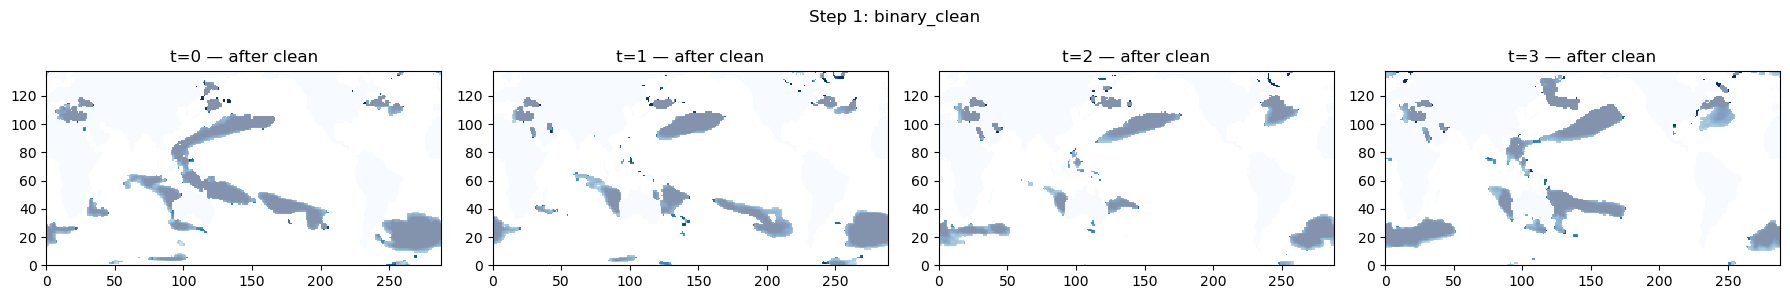

In [29]:
tracker2.clean()

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for t, ax in enumerate(axes):
    ax.pcolormesh(features[t], cmap='Blues', vmin=0, vmax=1)
    ax.pcolormesh(np.where(tracker2.binary_clean.isel(time=t).values, 1, np.nan),
                  cmap='Reds', alpha=0.5)
    ax.set_title(f't={t} — after clean')
plt.suptitle('Step 1: binary_clean')
plt.tight_layout()
plt.show()

Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)


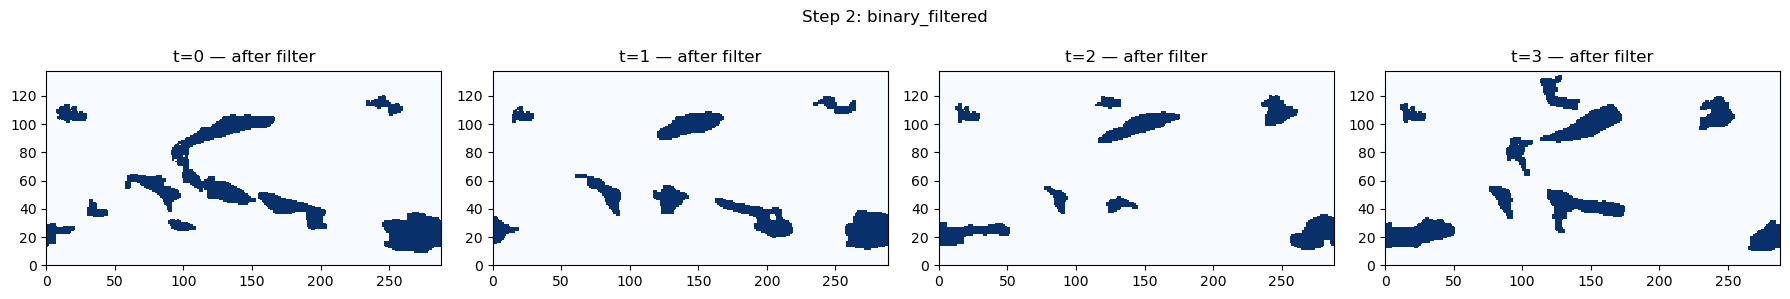

area threshold : 100 cells
initial objects: 791
area distribution:
  min    : 3
  median : 61
  max    : 3682


In [30]:
tracker2.filter()

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for t, ax in enumerate(axes):
    ax.pcolormesh(tracker2.binary_filtered.isel(time=t).values, cmap='Blues')
    ax.set_title(f't={t} — after filter')
plt.suptitle('Step 2: binary_filtered')
plt.tight_layout()
plt.show()

print(f"area threshold : {tracker2.min_area:.0f} cells")
print(f"initial objects: {tracker2.N_initial}")
print(f"area distribution:")
print(f"  min    : {float(tracker2.area.min()):.0f}")
print(f"  median : {float(tracker2.area.median()):.0f}")
print(f"  max    : {float(tracker2.area.max()):.0f}")

Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 87


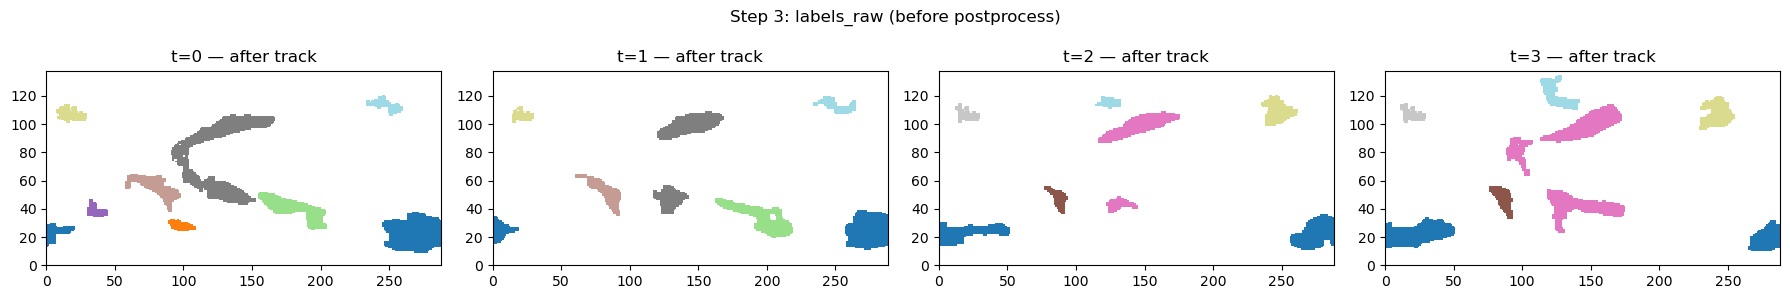

unique labels before postprocess: 87


In [31]:
tracker2.track()

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
cmap_raw = plt.colormaps.get_cmap('tab20').resampled(int(tracker2.labels_raw.max()) + 2)
for t, ax in enumerate(axes):
    raw = tracker2.labels_raw[t].astype(float)
    ax.pcolormesh(np.where(raw > 0, raw, np.nan), cmap=cmap_raw)
    ax.set_title(f't={t} — after track')
plt.suptitle('Step 3: labels_raw (before postprocess)')
plt.tight_layout()
plt.show()

print(f"unique labels before postprocess: {len(np.unique(tracker2.labels_raw[tracker2.labels_raw > 0]))}")

Step 4 · wrapping result …
    final events: 87


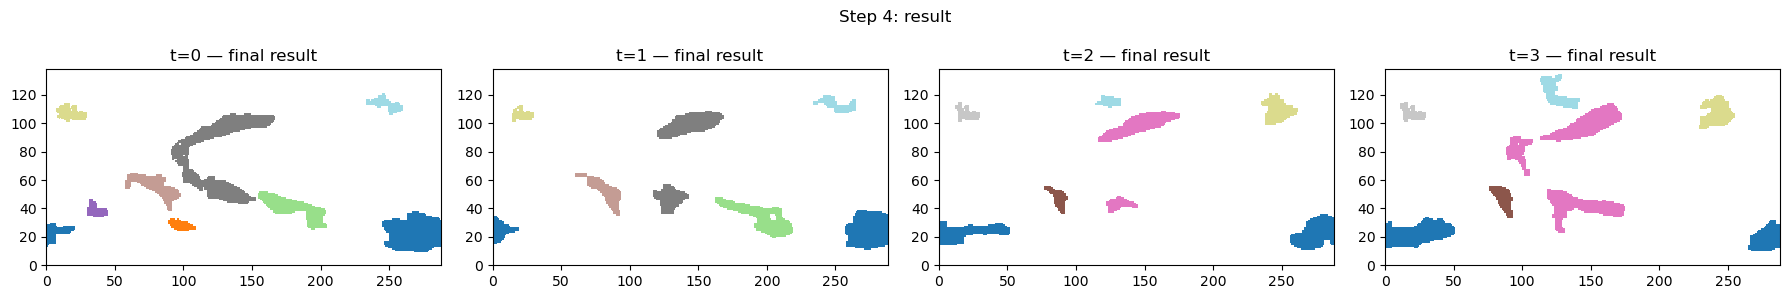

final events: 87
SurfTracker — Result Summary
  Input shape    : (40, 138, 288)
  Tracked events : 87
  Duration  min/median/max : 1 / 1 / 22
    >=  1 ts : 87
    >=  3 ts : 28
    >=  6 ts : 11
    >= 12 ts : 4

  Parameters:
    radius               = 2
    min_area_cells       = 100
    min_size_quartile    = 0.25
    positive             = True
    method               = temporal_neighbor
    steps_before         = 1
    steps_after          = 1
    min_overlap          = 0.5


In [32]:
tracker2.postprocess()

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
n_ev = tracker2.n_events()
cmap_ev = plt.colormaps.get_cmap('tab20').resampled(n_ev + 2)
for t, ax in enumerate(axes):
    res = tracker2.result.isel(time=t).values
    ax.pcolormesh(np.where(~np.isnan(res), res, np.nan), cmap=cmap_ev)
    ax.set_title(f't={t} — final result')
plt.suptitle('Step 4: result')
plt.tight_layout()
plt.show()

print(f"final events: {tracker2.n_events()}")
tracker2.summary()

### Plotting

In [40]:
lon = mask.lon
lat = mask.lat
mask_2d = mask

In [42]:
n_colors=87
cmap_ev  = plt.colormaps.get_cmap('prism')

In [ ]:
def plot_labels_with_event_ids(ax, labels_2d, title, lon, lat, mask_2d):
    plot_data = np.where(labels_2d > 0, labels_2d.astype(float), np.nan)
    ax.pcolormesh(lon, lat, plot_data, cmap=cmap_ev, vmin=1, vmax=n_colors)
    ax.pcolormesh(lon, lat, np.where(mask_2d == 0, 1, np.nan),
                  cmap='Greys', vmin=0, vmax=1, alpha=0.55)

    unique_events = np.unique(labels_2d)
    unique_events = unique_events[unique_events > 0]

    for event_id in unique_events:
        event_mask = (labels_2d == event_id)
        labeled_blobs, num_blobs = ndimage.label(event_mask)

        for blob_id in range(1, num_blobs + 1):
            blob_mask = (labeled_blobs == blob_id)
            y_indices, x_indices = np.where(blob_mask)

            if len(y_indices) > 0:
                y_center = int(np.mean(y_indices))
                x_center = int(np.mean(x_indices))
                lat_center = float(lat[y_center])
                lon_center = float(lon[x_center])

                ax.text(lon_center, lat_center, str(event_id),
                        color='white', fontsize=11, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='circle,pad=0.15',
                                  facecolor='black',
                                  edgecolor='white',
                                  linewidth=1.5,
                                  alpha=0.8))

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Longitude')

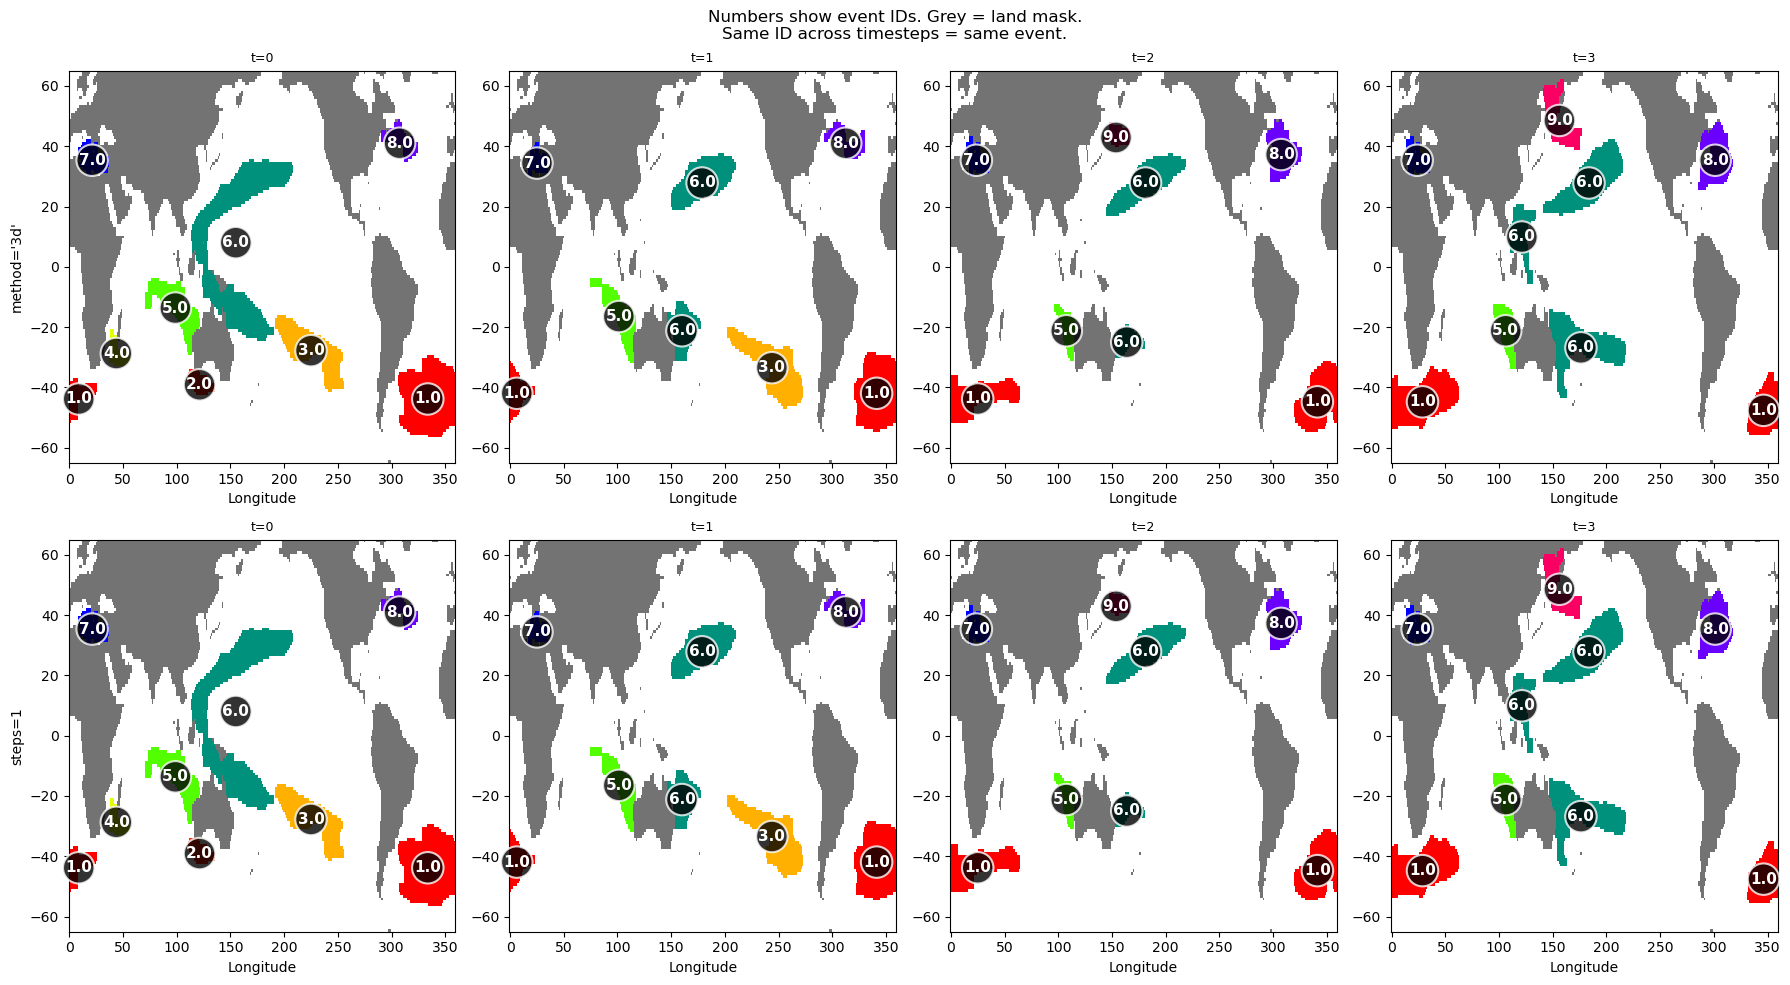

In [47]:
t_labels = [f't={t}' for t in range(4)]

rows = [
    (result3d,   "method='3d'"),
    (result,     "steps=1"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for row, (labels, row_label) in enumerate(rows):
    for col in range(4):
        plot_labels_with_event_ids(
            axes[row, col], labels[col], t_labels[col], lon, lat, mask_2d
        )
    axes[row, 0].set_ylabel(row_label, fontsize=10)

fig.suptitle(
    'Numbers show event IDs. Grey = land mask.\n'
    'Same ID across timesteps = same event.',
    fontsize=12,
)
plt.tight_layout()
plt.show()

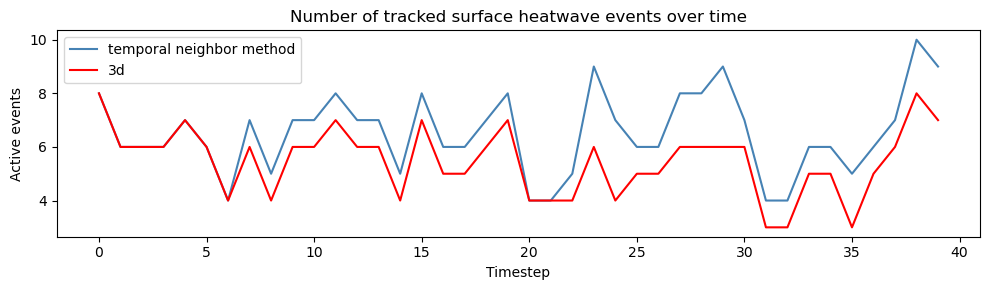

In [50]:
n_per_t = [
    len(np.unique(result.isel(time=t).values[
        ~np.isnan(result.isel(time=t).values)
    ]))
    for t in range(result.shape[0])
]

n_per_t_3d = [
    len(np.unique(result3d.isel(time=t).values[
        ~np.isnan(result3d.isel(time=t).values)
    ]))
    for t in range(result3d.shape[0])
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(n_per_t, lw=1.5, color='steelblue', label='temporal neighbor method')
ax.plot(n_per_t_3d, lw=1.5, color='red', label='3d')
ax.set_xlabel('Timestep'); ax.set_ylabel('Active events')
ax.set_title('Number of tracked surface heatwave events over time')
plt.legend()
plt.tight_layout(); plt.show(); plt.close()

Total events        : 87
Duration min/median/max : 1 / 1 / 22
  1 ts  : 46
  2 ts  : 13
  >= 3  : 28


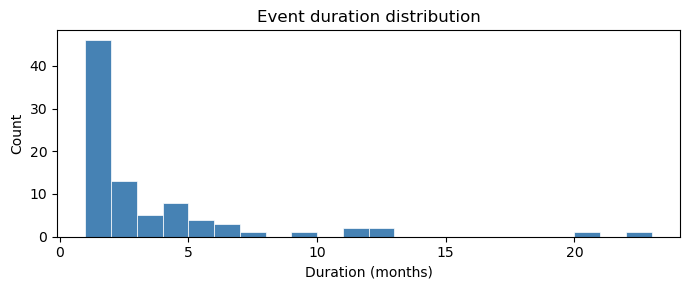

In [51]:
durations = tracker2.event_duration()
durs      = np.array(list(durations.values()))

print(f"Total events        : {len(durs)}")
print(f"Duration min/median/max : "
      f"{durs.min()} / {int(np.median(durs))} / {durs.max()}")
print(f"  1 ts  : {(durs == 1).sum()}")
print(f"  2 ts  : {(durs == 2).sum()}")
print(f"  >= 3  : {(durs >= 3).sum()}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(durs, bins=range(1, durs.max() + 2), edgecolor='white', linewidth=0.5,
        color='steelblue')
ax.set_xlabel('Duration (months)'); ax.set_ylabel('Count')
ax.set_title('Event duration distribution')
plt.tight_layout(); plt.show(); plt.close()